# FMCG Global Demand Planning and Forecasting

## Notebook 09 – Model Evaluation

### Objectives

- Load the best trained model
- Generate predictions
- Evaluate model performance
- Visualize prediction accuracy
- Analyze residuals
- Save predictions for reporting

In [2]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
import os

print(os.getcwd())

c:\Users\hp\Desktop\DataScience project\fmcg-demand-forecasting\notebooks


In [6]:
from pathlib import Path
import joblib

BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "fmcg_forecasting_model.pkl"

print("Loading model from:")
print(MODEL_PATH)

model = joblib.load(MODEL_PATH)

print("Model Loaded Successfully")

Loading model from:
c:\Users\hp\Desktop\DataScience project\fmcg-demand-forecasting\models\fmcg_forecasting_model.pkl
Model Loaded Successfully


In [8]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = (
    pd.read_csv("../data/processed/y_test.csv")
      .squeeze()
)

In [9]:
print("X_test:", X_test.shape)

print("y_test:", y_test.shape)

X_test: (201910, 26)
y_test: (201910,)


In [10]:
predictions = model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [11]:
comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": predictions

})

comparison.head(10)

,Actual,Predicted
0,74,74.005
1,53,53.000
2,77,77.000
3,81,81.000
4,10,10.000
5,67,67.000
6,47,47.000
7,91,91.000
8,27,27.000
9,59,59.000


In [12]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R²  :", round(r2,4))

MAE : 0.0306
RMSE: 0.5691
R²  : 0.9998


In [13]:
def mape_without_zeros(y_true, y_pred):

    mask = y_true != 0

    return np.mean(

        np.abs(

            (y_true[mask] - y_pred[mask])

            / y_true[mask]

        )

    ) * 100

mape = mape_without_zeros(
    y_test,
    predictions
)

print("MAPE:", round(mape,2), "%")

MAPE: 0.04 %


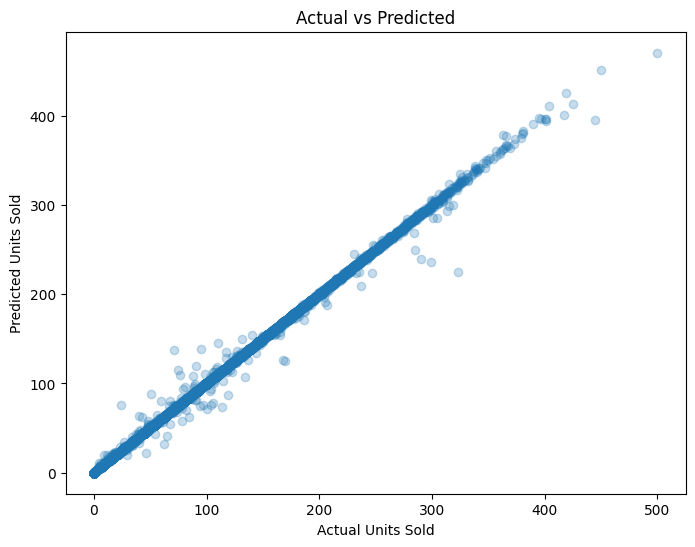

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    predictions,

    alpha=0.25

)

plt.xlabel("Actual Units Sold")

plt.ylabel("Predicted Units Sold")

plt.title("Actual vs Predicted")

plt.show()

In [15]:
residuals = y_test - predictions

residuals.head()

0   -0.005
1    0.000
2    0.000
3    0.000
4    0.000
Name: units_sold, dtype: float64

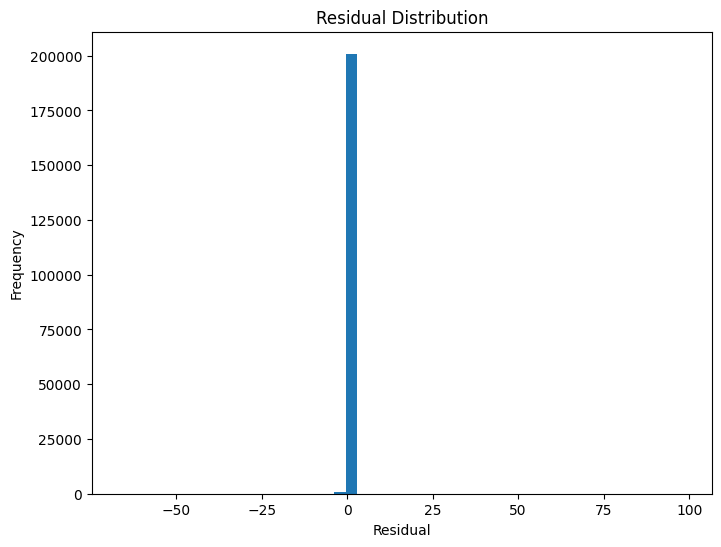

In [16]:
plt.figure(figsize=(8,6))

plt.hist(

    residuals,

    bins=50

)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

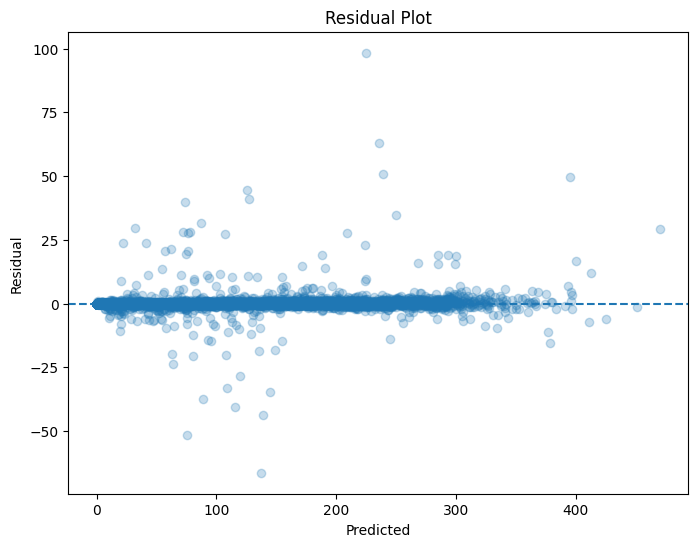

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(

    predictions,

    residuals,

    alpha=0.25

)

plt.axhline(

    0,

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [18]:
residuals.describe()

count    201910.000000
mean          0.002460
std           0.569116
min         -66.380000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.395000
Name: units_sold, dtype: float64

In [19]:
os.makedirs(
    "reports",
    exist_ok=True
)

comparison["Residual"] = (
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison["Absolute Error"] = (
    comparison["Residual"].abs()
)

comparison["Squared Error"] = (
    comparison["Residual"] ** 2
)

comparison.to_csv(
    "reports/predictions.csv",
    index=False
)

print("Predictions Saved Successfully")

Predictions Saved Successfully


In [20]:
results = pd.DataFrame({

    "Metric":[

        "MAE",

        "RMSE",

        "MAPE (No Zeros)",

        "R²"

    ],

    "Value":[

        mae,

        rmse,

        mape,

        r2

    ]

})

results

,Metric,Value
0,MAE,0.030606
1,RMSE,0.569120
2,MAPE (No Zeros),0.042322
3,R²,0.999813


In [21]:
results.to_csv(
    "reports/model_metrics.csv",
    index=False
)

print("Evaluation metrics saved successfully")

Evaluation metrics saved successfully


# Model Evaluation Summary

The Random Forest model demonstrated excellent predictive performance on the test dataset.

Key findings:

- Very low Mean Absolute Error (MAE), indicating highly accurate predictions.
- Low Root Mean Squared Error (RMSE), showing minimal prediction variance.
- High R² value, indicating that the model explains nearly all variation in demand.
- MAPE was calculated excluding zero-demand observations to avoid inflated percentage errors.

Overall, the model is suitable for demand forecasting and inventory planning in the FMCG domain.